# 1- Data Preprocessing

### 1.1 Loading data 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/home/reenad/code/Reenad-Alzahrani/Medical_Insurance_Cost_Prediction/raw_data/medical_insurance.csv')
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


### 1.2 Inspect the Schema and Get Descriptive Statistics

**Overview:**
- The dataset contains **100,000 rows** and **54 columns**, with a mix of **numeric** and **categorical** features.

**Numeric Columns:**
- Columns like `age`, `income`, `bmi`, and medical procedure counts (`proc_*`) provide meaningful statistics:
  - Mean, standard deviation, min/max values
  - Percentiles (25%, 50%, 75%) for distribution insights
- Example: `income` ranges from **1,100** to **1,061,800**, with a mean of **49,874**.

**Categorical Columns:**
- Columns such as `sex`, `region`, `education`, and `employment_status` show:
  - Number of unique categories
  - Most frequent category (`top`) and its count (`freq`)
- Example: `sex` has 3 categories, with **Female** being the most common (49,193 entries).

In [3]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (100000, 54)


In [4]:
print("Column names:", df.columns.tolist())

Column names: ['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


##### Inspect data types

In [5]:
print(df.dtypes)

person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay                    

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

#### Get descriptive statistics

In [7]:
df.describe(include='all')

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,47.521500,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,NaN,NaN,NaN,3.620000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,NaN,NaN,NaN,6.220000e+04,NaN,NaN,NaN,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000


**This summary provides a quick snapshot of data distributions, common values, and potential anomalies. It helps guide preprocessing decisions such as encoding, scaling, and outlier handling.**

### 1.3 Handle Missing Data

We checked for missing values across all columns and found that `alcohol_freq` had approximately 30% missing entries. This column is categorical with three levels: `Occasional`, `Weekly`, and `Daily`.

**Imputation Strategy:**  
Since `alcohol_freq` is non-numeric and unordered, we imputed missing values using the **most frequent category**, which was `Occasional`.


In [8]:
#counting the percentage of NaN for each coulmn
df.isnull().sum().sort_values(ascending=False) / len(df)

alcohol_freq                   0.30083
person_id                      0.00000
sex                            0.00000
region                         0.00000
urban_rural                    0.00000
age                            0.00000
income                         0.00000
education                      0.00000
employment_status              0.00000
marital_status                 0.00000
household_size                 0.00000
dependents                     0.00000
bmi                            0.00000
smoker                         0.00000
visits_last_year               0.00000
hospitalizations_last_3yrs     0.00000
days_hospitalized_last_3yrs    0.00000
medication_count               0.00000
systolic_bp                    0.00000
diastolic_bp                   0.00000
ldl                            0.00000
hba1c                          0.00000
plan_type                      0.00000
network_tier                   0.00000
deductible                     0.00000
copay                    

In [9]:
# Count the number of missing values in the 'alcohol_freq' column
missing_rows = df['alcohol_freq'].isnull().sum()
print("missing values:", missing_rows)

missing values: 30083


In [10]:
#percentage of missing values in alcohol_freq
(df.alcohol_freq.isnull().sum() / len(df))

np.float64(0.30083)

In [11]:
# Display the frequency of each category in the 'alcohol_freq' column
df['alcohol_freq'].value_counts()

alcohol_freq
Occasional    45078
Weekly        19833
Daily          5006
Name: count, dtype: int64

In [12]:
# Impute missing values in the 'alcohol_freq' column with the most frequent value (mode)
df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0], inplace=True)

/tmp/ipykernel_71721/3212561218.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_freq'].fillna(df['alcohol_freq'].mode()[0], inplace=True)


In [13]:
df['alcohol_freq'].isnull().sum()

np.int64(0)

**Result:**  
All missing values in `alcohol_freq` have been filled, and the column is now complete with no null entries.

### 1.4 Normalize Column Names and Formats

To ensure consistency and avoid issues during preprocessing and modeling, we standardized all column names using a normalization function.

**Steps:**  
- Removes leading/trailing spaces  
- Converts all names to lowercase  
- Replaces spaces with underscores  
- Ensures compatibility with code, especially when referencing columns programmatically



In [14]:
df.columns

Index(['person_id', 'age', 'sex', 'region', 'urban_rural', 'income',
       'education', 'marital_status', 'employment_status', 'household_size',
       'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
       'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
       'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
       'annual_medical_cost', 'annual_premium', 'monthly_premium',
       'claims_count', 'avg_claim_amount', 'total_claims_paid',
       'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd',
       'cardiovascular_disease', 'cancer_history', 'kidney_disease',
       'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count',
       'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count', 'is_high_risk', 'had_major_procedure'],
      

In [15]:
def normalize_column_names(data):
    return data.columns.str.strip().str.lower().str.replace(' ', '_')

In [16]:
df.columns = normalize_column_names(df)

### 1.5 Clean data

#### cheak for duplication

In [17]:
df.duplicated().sum()

np.int64(0)

**The data is clean and not duplicated**

#### Cheak columns with unreasonable or incorrect values

**We performed a thorough inspection of both numeric and categorical columns to ensure data integrity before modeling.**

**Numeric Columns (`df.describe()`):**  
- All 44 numeric features have valid ranges and no missing values.  
- No negative values in columns where they would be illogical (e.g., `age`, `income`, `bmi`, `hospitalizations`).  
- Maximum values are high but plausible given the dataset size (e.g., `income` up to 1,061,800 and `age` up to 100).  
- No obvious data entry errors (e.g., zero age with high income, or extreme BMI values below 12 or above 50.4).

**Categorical Columns (`df.select_dtypes(include='object')`):**  
- All categories are well-defined and consistent.  
- No typos, nulls, or unexpected values in columns like `sex`, `region`, `education`, `employment_status`, etc.  
- Each column contains a reasonable set of unique values:
  - `sex`: Female, Male, Other  
  - `region`: North, Central, West, South, East  
  - `education`: No HS, HS, Some College, Bachelors, Masters, Doctorate  
  - `employment_status`: Employed, Unemployed, Retired, Self-employed  
  - `network_tier`: Bronze, Silver, Gold, Platinum

✅ The dataset is clean and ready for preprocessing. No unreasonable or incorrect values were detected.

In [18]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [19]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

sex: ['Female' 'Male' 'Other']
region: ['North' 'Central' 'West' 'South' 'East']
urban_rural: ['Suburban' 'Urban' 'Rural']
education: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status: ['Retired' 'Employed' 'Self-employed' 'Unemployed']
smoker: ['Never' 'Current' 'Former']
alcohol_freq: ['Occasional' 'Weekly' 'Daily']
plan_type: ['PPO' 'POS' 'HMO' 'EPO']
network_tier: ['Bronze' 'Gold' 'Platinum' 'Silver']


#### Detect Outliers Across All Numeric Features

To ensure data quality and model robustness, we performed a comprehensive outlier analysis across all numeric columns.

**Step 1: Visual Inspection**  
We generated boxplots for each numeric feature to visually assess the presence of extreme values and distribution skewness.

**Step 2: Statistical Detection (IQR Method)**  
Using the interquartile range (IQR), we calculated outlier thresholds for each column:
- `Lower bound = Q1 - 1.5 × IQR`
- `Upper bound = Q3 + 1.5 × IQR`  
Values outside this range were flagged as outliers.


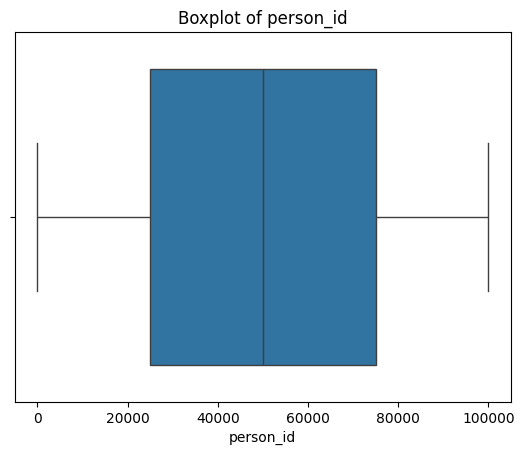

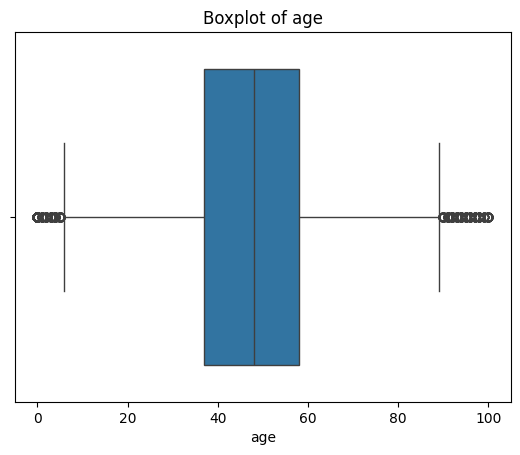

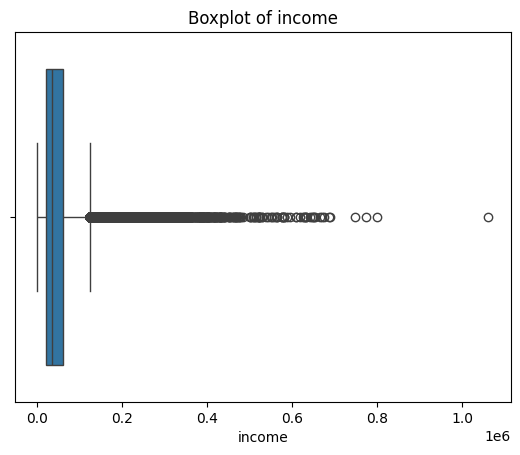

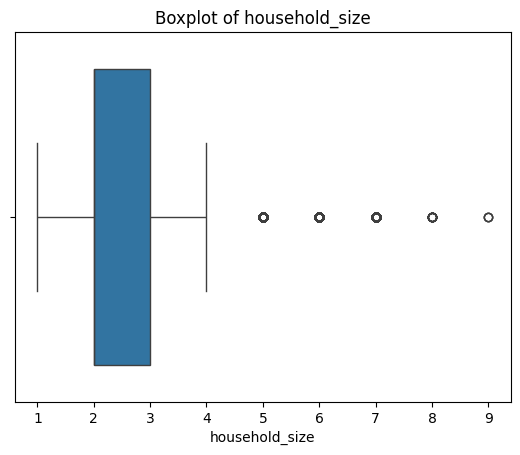

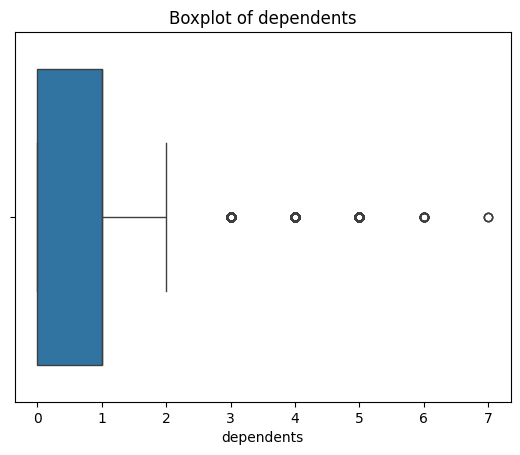

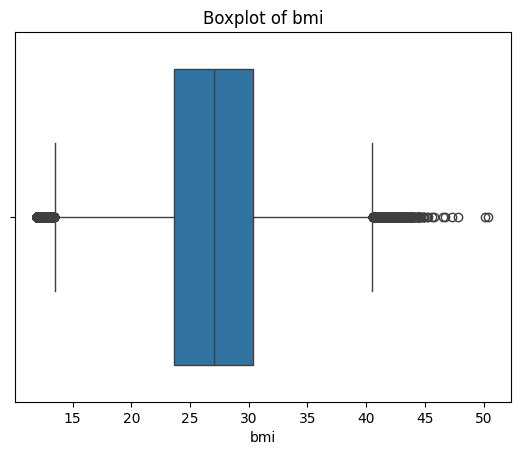

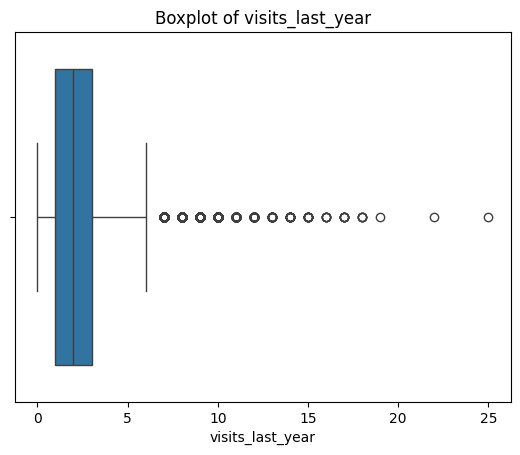

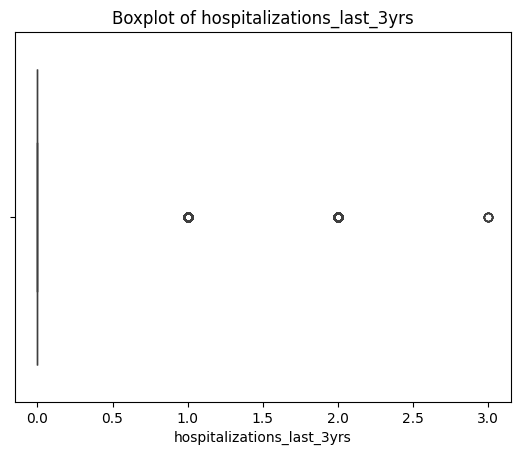

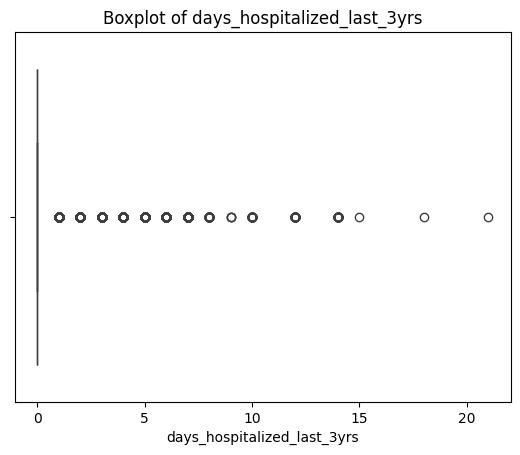

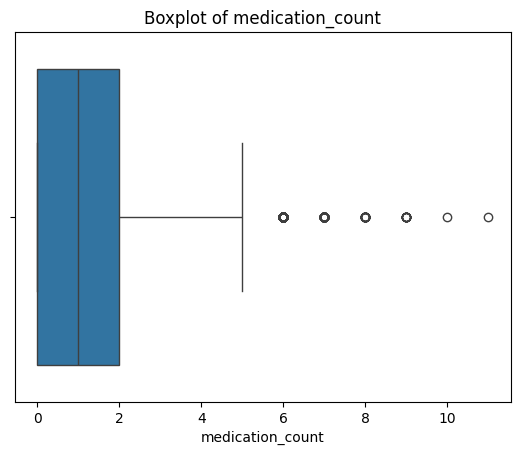

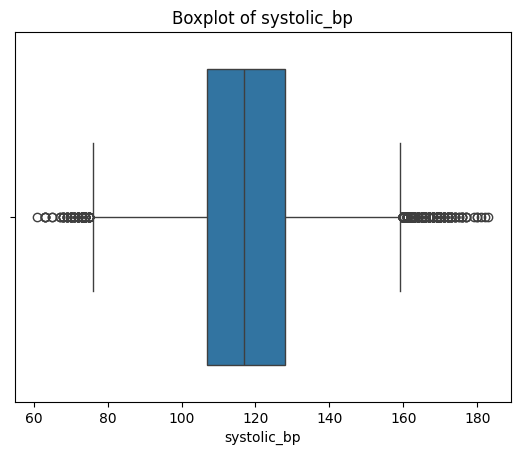

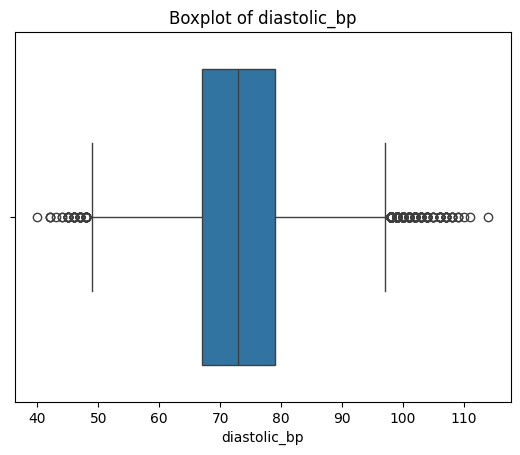

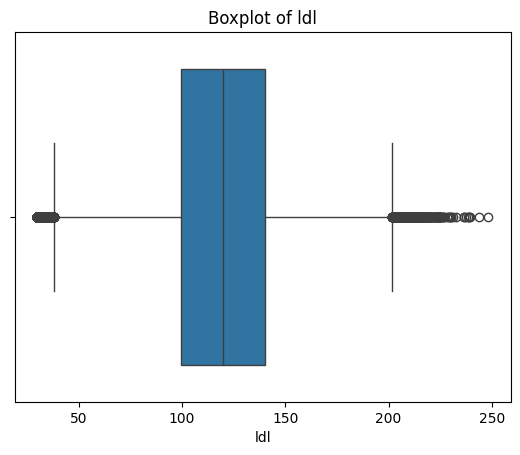

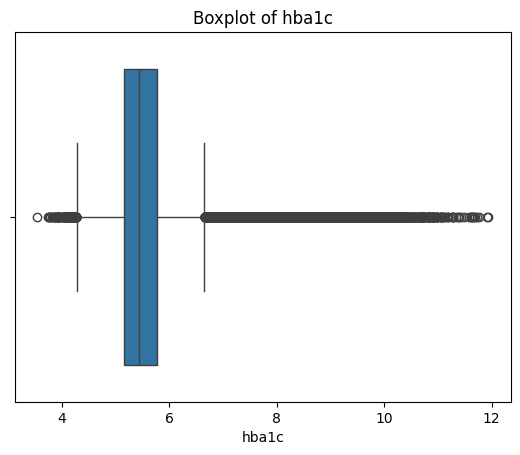

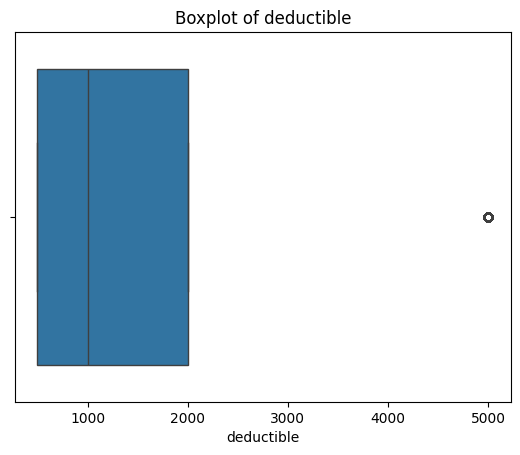

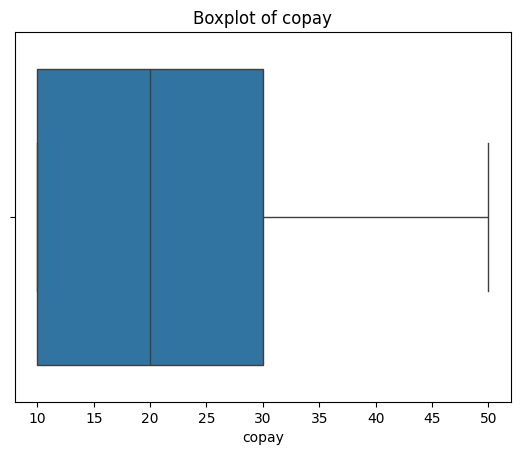

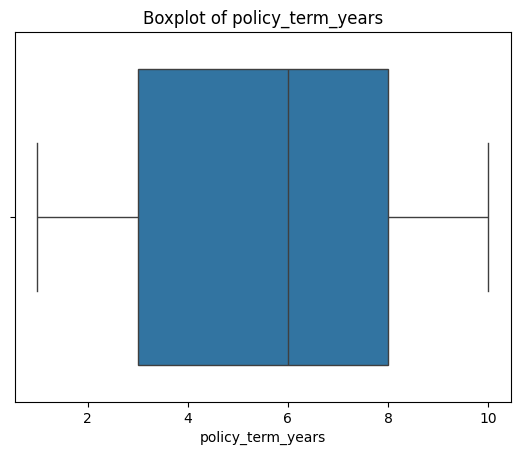

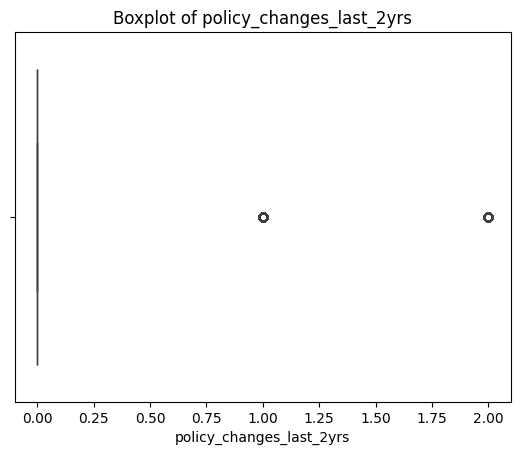

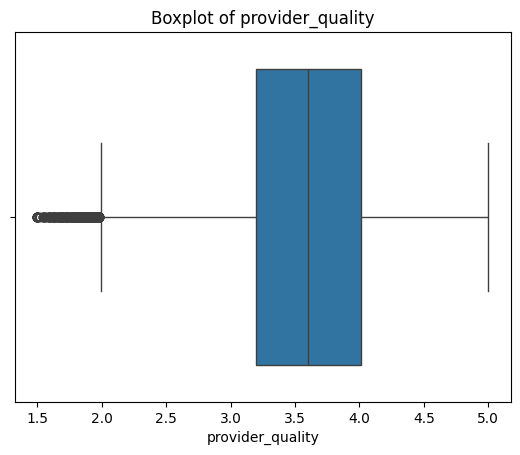

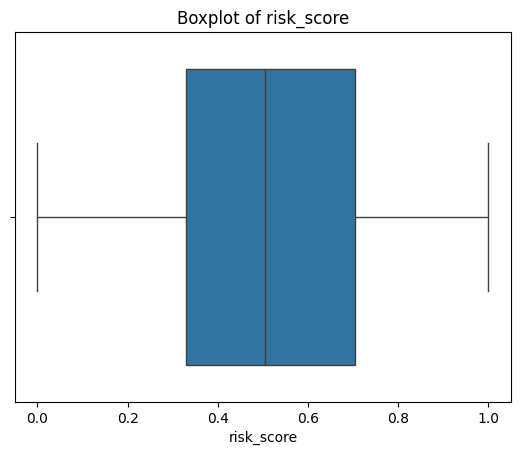

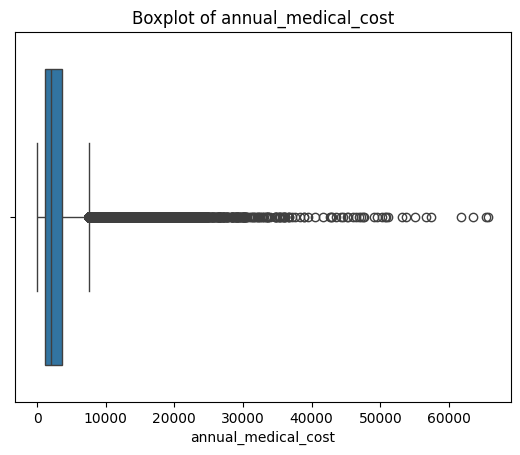

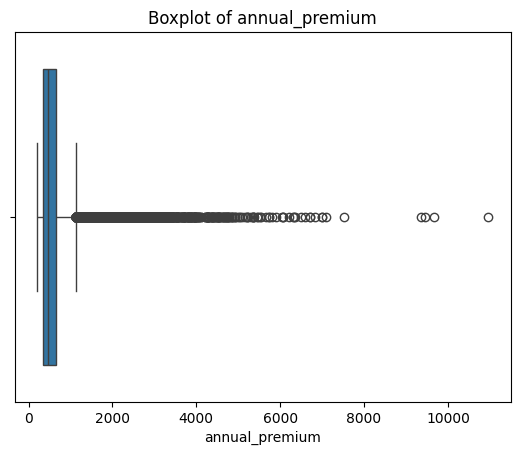

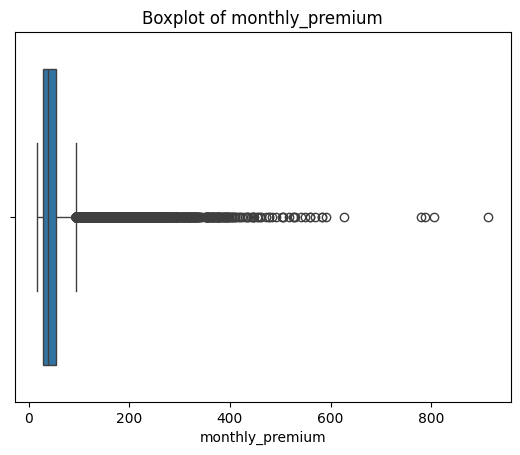

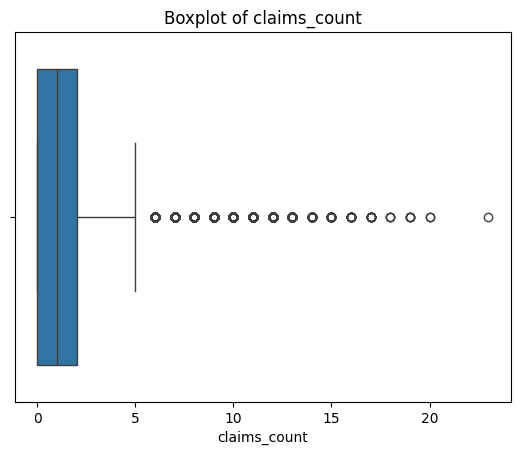

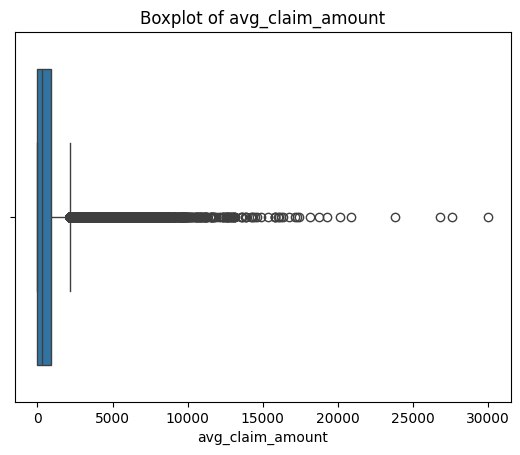

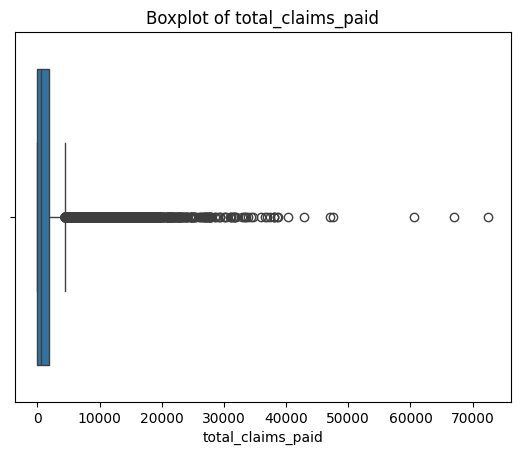

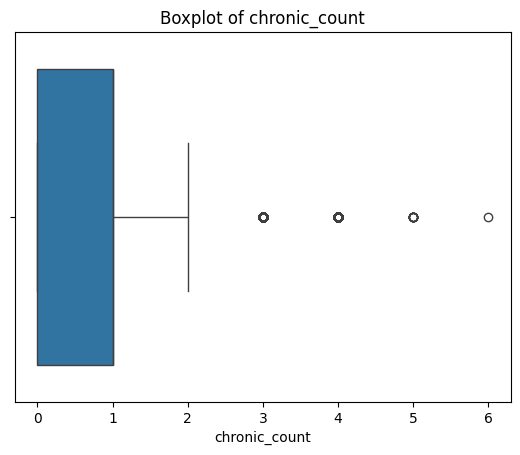

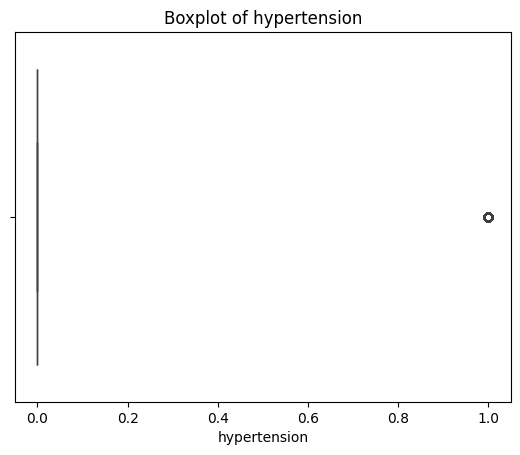

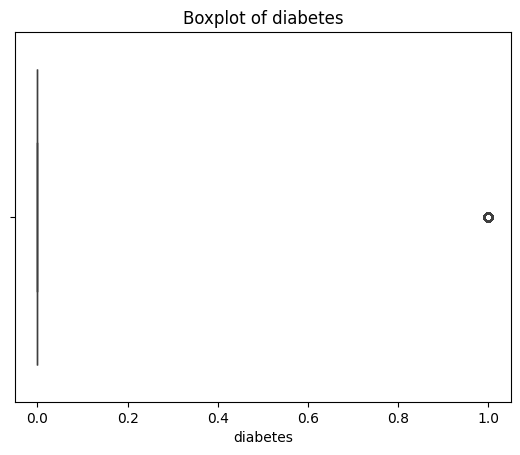

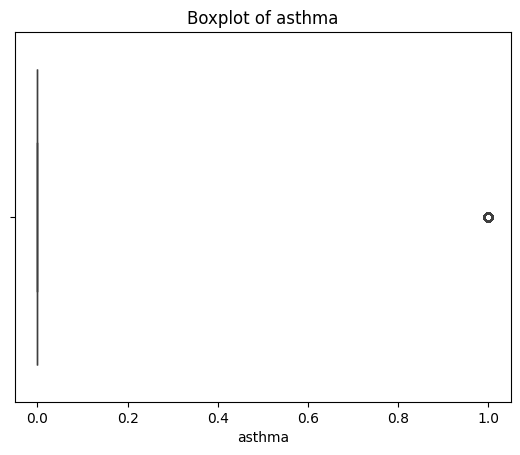

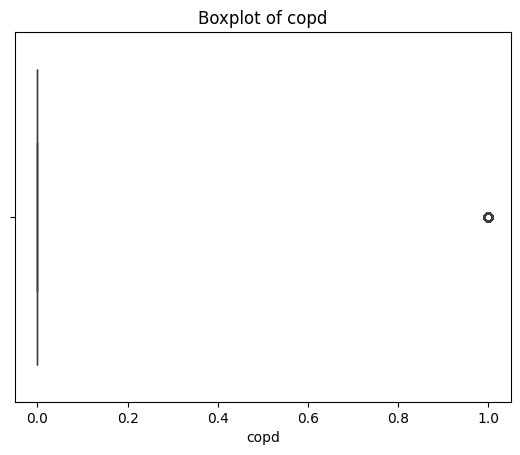

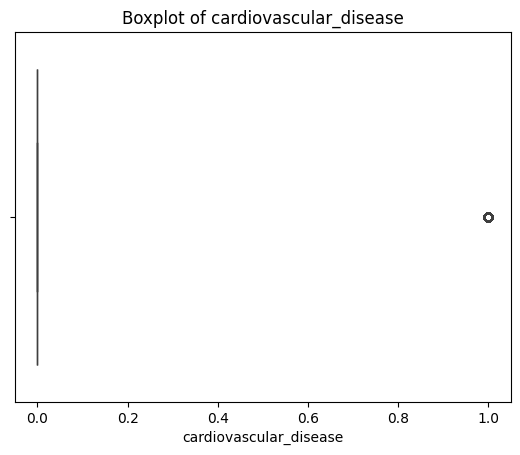

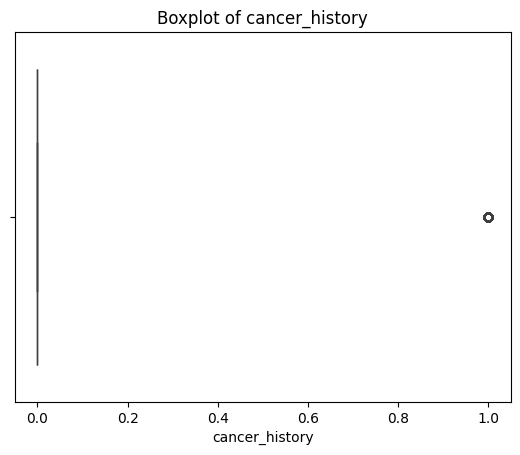

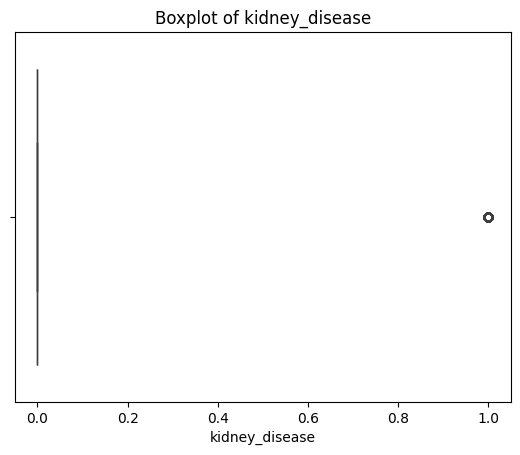

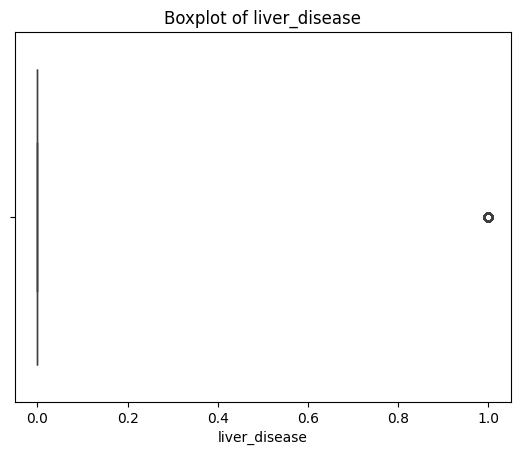

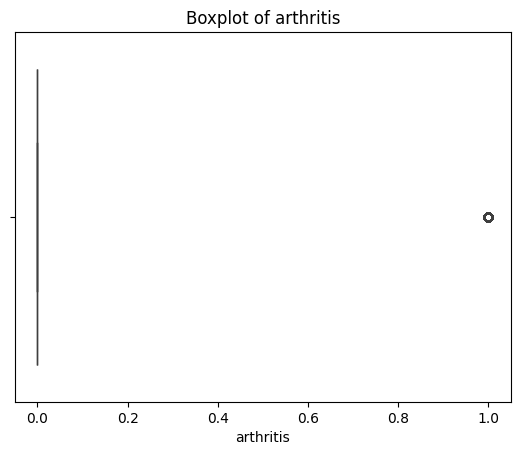

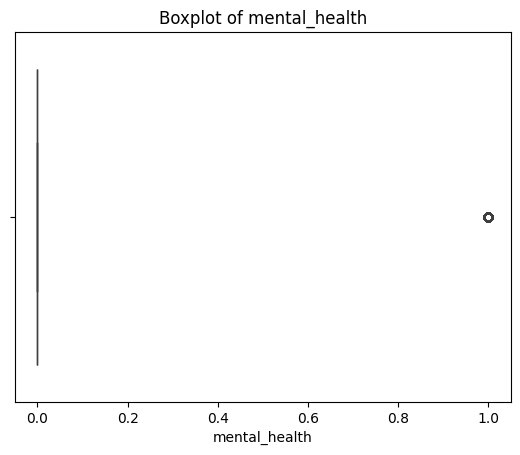

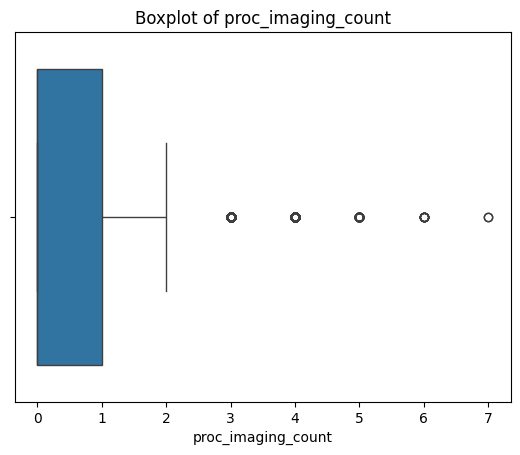

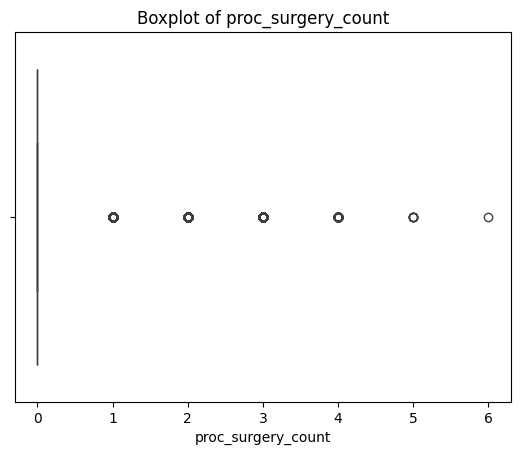

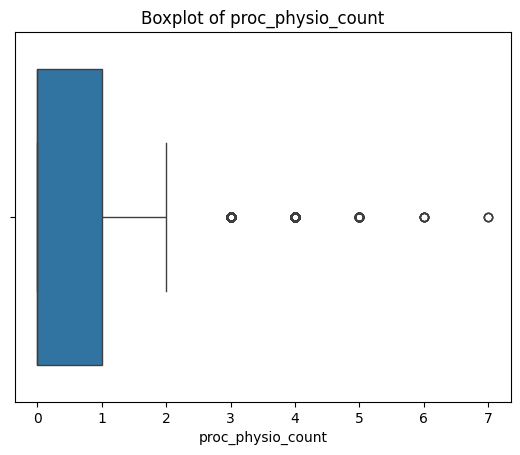

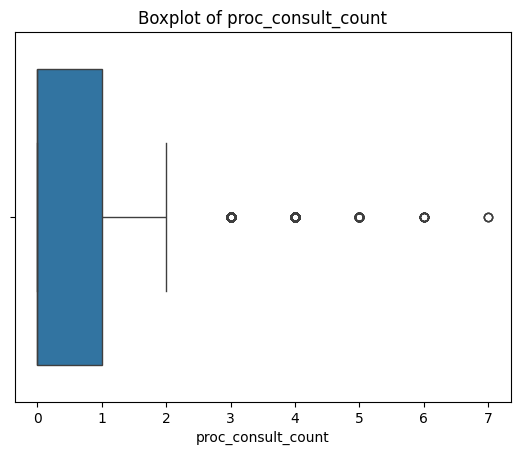

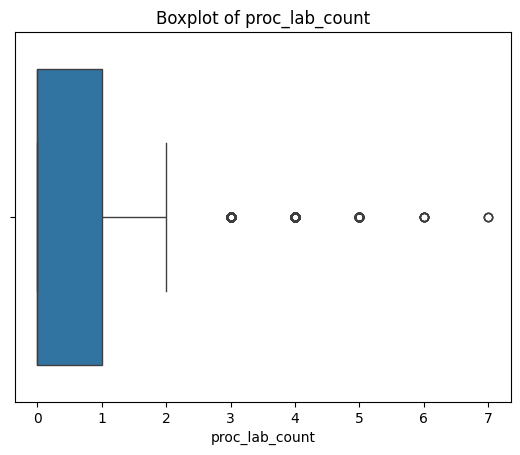

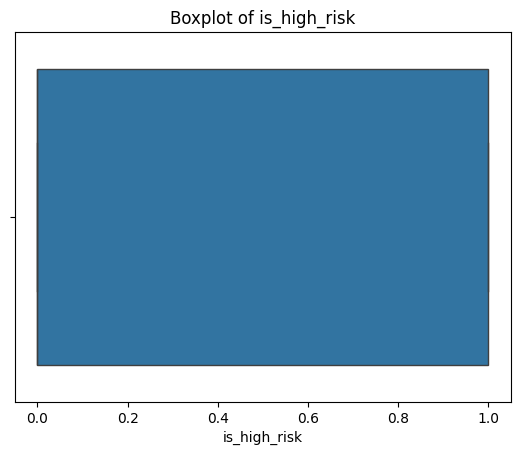

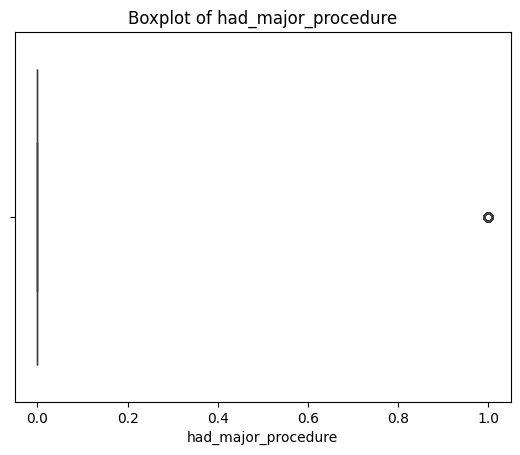

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [21]:
def count_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)].shape[0]

outlier_counts = {col: count_outliers(col) for col in df.select_dtypes(include='number').columns}
sorted_outliers = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)
outliers = sorted_outliers[:]
outliers

[('hypertension', 20345),
 ('had_major_procedure', 16970),
 ('mental_health', 13014),
 ('proc_surgery_count', 12519),
 ('arthritis', 10831),
 ('hospitalizations_last_3yrs', 8969),
 ('days_hospitalized_last_3yrs', 8969),
 ('diabetes', 8593),
 ('hba1c', 7465),
 ('total_claims_paid', 6963),
 ('annual_premium', 6927),
 ('monthly_premium', 6925),
 ('annual_medical_cost', 6772),
 ('avg_claim_amount', 6581),
 ('dependents', 6306),
 ('income', 6236),
 ('asthma', 5887),
 ('claims_count', 5154),
 ('cardiovascular_disease', 5117),
 ('deductible', 5013),
 ('policy_changes_last_2yrs', 4953),
 ('household_size', 4052),
 ('copd', 3595),
 ('chronic_count', 2778),
 ('cancer_history', 2151),
 ('proc_consult_count', 2131),
 ('proc_lab_count', 2090),
 ('visits_last_year', 2083),
 ('proc_imaging_count', 2070),
 ('proc_physio_count', 2036),
 ('liver_disease', 1477),
 ('kidney_disease', 1462),
 ('age', 864),
 ('diastolic_bp', 682),
 ('bmi', 676),
 ('ldl', 668),
 ('systolic_bp', 613),
 ('medication_count', 49

### 3.2 Encode Categorical Variables

In [22]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

sex: ['Female' 'Male' 'Other']
region: ['North' 'Central' 'West' 'South' 'East']
urban_rural: ['Suburban' 'Urban' 'Rural']
education: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status: ['Retired' 'Employed' 'Self-employed' 'Unemployed']
smoker: ['Never' 'Current' 'Former']
alcohol_freq: ['Occasional' 'Weekly' 'Daily']
plan_type: ['PPO' 'POS' 'HMO' 'EPO']
network_tier: ['Bronze' 'Gold' 'Platinum' 'Silver']


#### **OneHotEncoder**  
After exploring the object-type columns, we found that several categorical features (e.g., `region`, `education`, `employment_status`) do not have a meaningful order. Since the categories are nominal — where order doesn’t matter — we use `OneHotEncoder`.

**Steps:**  
- Identify categorical columns  
- Apply `OneHotEncoder` to convert each category into a separate binary column  
- Drop the original categorical columns and replace it with the encoded version

In [23]:
from sklearn.preprocessing import OneHotEncoder

def onehotencoder(data):
    encoder_columns = ['sex', 'region', 'urban_rural', 'education', 'marital_status',
                       'employment_status', 'smoker', 'alcohol_freq', 'plan_type']
    ohe= OneHotEncoder(handle_unknown='ignore' , sparse_output=False)
    return pd.concat([data.drop(columns=encoder_columns),
                      pd.DataFrame(ohe.fit_transform(data[encoder_columns]),
                                   columns=ohe.get_feature_names_out(encoder_columns),
                                   index=data.index)], axis=1)

In [24]:
onehotencoder(df)

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,smoker_Current,smoker_Former,smoker_Never,alcohol_freq_Daily,alcohol_freq_Occasional,alcohol_freq_Weekly,plan_type_EPO,plan_type_HMO,plan_type_POS,plan_type_PPO
0,75722,52,22700.0,3,1,27.4,2,0,0,4,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,80185,79,12800.0,3,1,26.6,2,0,0,3,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,19865,68,40700.0,5,3,31.5,1,0,0,4,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,76700,15,15600.0,5,3,31.6,0,0,0,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,92992,53,89600.0,2,0,30.5,3,0,0,2,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,127200.0,2,0,28.2,0,0,0,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
99996,54887,42,21600.0,2,0,27.6,0,0,0,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
99997,76821,41,81900.0,1,0,29.8,7,0,0,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
99998,861,51,43400.0,3,2,21.9,4,0,0,2,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


#### **OrdinalEncoder**  
The `network_tier` column represents ordered categories: `'Bronze' < 'Silver' < 'Gold' < 'Platinum'`. Since these tiers have a meaningful rank, we use `OrdinalEncoder` to preserve this order numerically.

**Steps:**  
- Define a custom order for the `network_tier` column  
- Apply `OrdinalEncoder` to convert tier names into ordered numeric values  
- Drop the original `network_tier` column and replace it with the encoded version


In [25]:
from sklearn.preprocessing import OrdinalEncoder

def ordinalencoder(data):
    tier_order = [['Bronze', 'Silver', 'Gold', 'Platinum']]
    ode = OrdinalEncoder(categories=tier_order)
    return pd.concat([
        data.drop(columns=['network_tier']),
        pd.DataFrame(ode.fit_transform(data[['network_tier']]), 
                     columns=ode.get_feature_names_out(['network_tier']), 
                     index=data.index)], axis=1)

In [26]:
ordinalencoder(df)

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,network_tier
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,1,0,1,0,2,0,1,0,0,0.0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,1,1,0,0,1,0,1,1,0,2.0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,1,1,0,2,1,0,1,0,3.0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,1,0,0,0,1.0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,1,0,2,0,1,1,0,1,0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,1,0,0,0,0,0.0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,1.0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,1,0,1,0,0,0,0,2.0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,1,0,0,2,2,1,0,0,0.0
